AUTOMATING CRYPTO WEBSITE PROJECT

In [2]:
# code snippet taken from coinmarket api page
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '17bbb049-776d-481e-bdf5-2058bd03d8c2',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)
#NOTE
# Encountered a data rate limit and hence to mitigate the issue i typed in the command below:
# jupyter notebook --NotebookApp.iopub_data_rate_limit=1.0e10 in the terminal and this allowed me to pull data

{'status': {'timestamp': '2025-05-17T07:15:57.881Z', 'error_code': 0, 'error_message': None, 'elapsed': 19, 'credit_count': 1, 'notice': None, 'total_count': 9788}, 'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'num_market_pairs': 12070, 'date_added': '2010-07-13T00:00:00.000Z', 'tags': ['mineable', 'pow', 'sha-256', 'store-of-value', 'state-channel', 'coinbase-ventures-portfolio', 'three-arrows-capital-portfolio', 'polychain-capital-portfolio', 'binance-labs-portfolio', 'blockchain-capital-portfolio', 'boostvc-portfolio', 'cms-holdings-portfolio', 'dcg-portfolio', 'dragonfly-capital-portfolio', 'electric-capital-portfolio', 'fabric-ventures-portfolio', 'framework-ventures-portfolio', 'galaxy-digital-portfolio', 'huobi-capital-portfolio', 'alameda-research-portfolio', 'a16z-portfolio', '1confirmation-portfolio', 'winklevoss-capital-portfolio', 'usv-portfolio', 'placeholder-ventures-portfolio', 'pantera-capital-portfolio', 'multicoin-capital-portfolio', 'para

In [2]:
type(data)

dict

Lets Begin to create our automating script

In [4]:
import pandas as pd

# This allows us to see all the columns, not only like 15
pd.set_option('display.max_columns', None)

In [6]:
# This normalizes the data and makes it all pretty in a dataframe
df = pd.json_normalize(data['data'])

# added a timestamp at the very end to show us when the last currencies were last run
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12070,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.986529e+07,1.986529e+07,False,NaN,1,NaN,NaN,None,2025-05-17T07:15:00.000Z,103560.222654,4.414724e+10,-13.0324,0.053410,-0.408353,-0.226734,22.292218,24.801114,6.274055,2.057254e+12,62.5358,2.174765e+12,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
1,1027,Ethereum,ETH,ethereum,10293,2015-08-07T00:00:00.000Z,"[pos, defi, smart-contracts, ethereum-ecosyste...",NaN,1.207277e+08,1.207277e+08,True,NaN,2,NaN,NaN,None,2025-05-17T07:15:00.000Z,2499.674802,2.441463e+10,-1.0762,0.122613,-3.450344,5.839331,56.144697,31.221618,-7.580962,3.017799e+11,9.1734,3.017799e+11,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
2,825,Tether USDt,USDT,tether,128164,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.510540e+11,1.555074e+11,True,NaN,3,NaN,NaN,None,2025-05-17T07:14:00.000Z,1.000280,7.224449e+10,-19.7636,0.023164,0.029886,0.019868,0.030991,0.038657,0.023040,1.510963e+11,4.5930,1.555510e+11,None,2025-05-17T07:14:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-05-17 09:16:07.551468
3,52,XRP,XRP,xrp,1608,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,5.862215e+10,9.998613e+10,False,NaN,4,NaN,NaN,None,2025-05-17T07:15:00.000Z,2.383713,3.520351e+09,-37.7675,0.484344,-0.997190,-0.076692,13.807423,4.819538,-14.279570,1.397384e+11,4.2477,2.383713e+11,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
4,1839,BNB,BNB,bnb,2527,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, defi, paym...",NaN,1.408887e+08,1.408887e+08,False,NaN,5,NaN,NaN,None,2025-05-17T07:14:00.000Z,645.024900,1.596133e+09,-15.6331,0.132084,-1.841554,-2.664696,10.693042,1.514778,-1.755289,9.087673e+10,2.7624,9.087673e+10,None,2025-05-17T07:14:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
5,5426,Solana,SOL,solana,917,2020-04-10T00:00:00.000Z,"[pos, platform, defi, solana-ecosystem, cms-ho...",NaN,5.198171e+08,6.009458e+08,True,NaN,6,NaN,NaN,None,2025-05-17T07:15:00.000Z,169.592411,3.600532e+09,-18.4763,0.479639,-1.259760,-1.357105,26.392049,35.994355,-12.644840,8.815703e+10,2.6798,1.019158e+11,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
6,3408,USDC,USDC,usd-coin,27934,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,6.092763e+10,6.092763e+10,False,NaN,7,NaN,NaN,None,2025-05-17T07:15:00.000Z,0.999830,9.545433e+09,-17.4236,-0.001379,0.004986,-0.014271,-0.009125,-0.008298,-0.008201,6.091728e+10,1.8517,6.091728e+10,None,2025-05-17T07:15:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-05-17 09:16:07.551468
7,74,Dogecoin,DOGE,dogecoin,1222,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,1.492974e+11,1.492974e+11,True,NaN,8,NaN,NaN,None,2025-05-17T07:15:00.000Z,0.218683,1.695323e+09,-31.0551,0.418511,-2.859873,-2.089656,39.375838,30.723694,-19.098050,3.264874e+10,0.9924,3.264874e+10,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
8,2010,Cardano,ADA,cardano,1516,2017-10-01T00:00:00.000Z,"[dpos, pos, platform, defi, research, smart-co...",4.50000

In [8]:
# were now going to make an automation script and first we create a function
def api_runner():    
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '17bbb049-776d-481e-bdf5-2058bd03d8c2',
    }
    
    session = Session()
    session.headers.update(headers)
    
    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)
        
    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True) # using concat because append() method was removed in pandas 2.0
    csv_file = r'/Users/taongasoko/Downloads/Projects/API.csv'


In [10]:
import os 
from time import time
from time import sleep

# we only have 333 runs per day for our specific api hence why were using that number
for i in range(333):
    api_runner()
    print('Api Runner completed successfully')
    # have it run every minute
    sleep(60) # sleep for 1 min
exit()

Api Runner completed successfully
Api Runner completed successfully
Api Runner completed successfully
Api Runner completed successfully


KeyboardInterrupt: 

In [12]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12070,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.986529e+07,1.986529e+07,False,NaN,1,NaN,NaN,None,2025-05-17T07:15:00.000Z,103560.222654,4.414724e+10,-13.0324,0.053410,-0.408353,-0.226734,22.292218,24.801114,6.274055,2.057254e+12,62.5358,2.174765e+12,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
1,1027,Ethereum,ETH,ethereum,10293,2015-08-07T00:00:00.000Z,"[pos, defi, smart-contracts, ethereum-ecosyste...",NaN,1.207277e+08,1.207277e+08,True,NaN,2,NaN,NaN,None,2025-05-17T07:15:00.000Z,2499.674802,2.441463e+10,-1.0762,0.122613,-3.450344,5.839331,56.144697,31.221618,-7.580962,3.017799e+11,9.1734,3.017799e+11,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
2,825,Tether USDt,USDT,tether,128164,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.510540e+11,1.555074e+11,True,NaN,3,NaN,NaN,None,2025-05-17T07:14:00.000Z,1.000280,7.224449e+10,-19.7636,0.023164,0.029886,0.019868,0.030991,0.038657,0.023040,1.510963e+11,4.5930,1.555510e+11,None,2025-05-17T07:14:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-05-17 09:16:07.551468
3,52,XRP,XRP,xrp,1608,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,5.862215e+10,9.998613e+10,False,NaN,4,NaN,NaN,None,2025-05-17T07:15:00.000Z,2.383713,3.520351e+09,-37.7675,0.484344,-0.997190,-0.076692,13.807423,4.819538,-14.279570,1.397384e+11,4.2477,2.383713e+11,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
4,1839,BNB,BNB,bnb,2527,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, defi, paym...",NaN,1.408887e+08,1.408887e+08,False,NaN,5,NaN,NaN,None,2025-05-17T07:14:00.000Z,645.024900,1.596133e+09,-15.6331,0.132084,-1.841554,-2.664696,10.693042,1.514778,-1.755289,9.087673e+10,2.7624,9.087673e+10,None,2025-05-17T07:14:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,20947,Sui,SUI,sui,653,2022-07-12T08:03:11.000Z,"[defi, binance-launchpool, coinbase-ventures-p...",1.000000e+10,3.338327e+09,1.000000e+10,False,NaN,11,3.338327e+09,1.278903e+10,None,2025-05-17T07:18:00.000Z,3.830970,1.115749e+09,-32.8174,-0.009125,-1.061786,-3.806467,82.524330,67.003863,13.481569,1.278903e+10,0.3885,3.830970e+10,None,2025-05-17T07:18:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:19:30.405384
71,1975,Chainlink,LINK,chainlink,2008,2017-09-20T00:00:00.000Z,"[platform, defi, oracles, smart-contracts, eth...",NaN,6.571000e+08,1.000000e+09,False,NaN,12,NaN,NaN,None,2025-05-17T07:17:00.000Z,15.511428,3.952664e+08,-31.2061,0.095292,-4.882257,-4.686705,23.100617,9.927049,-18.287487,1.019256e+10,0.3097,1.551143e+10,None,2025-05-17T07:17:00.000Z,1027.0,Ethereum,ETH,ethereum,0x514910771af9ca656af840dff83e8264ecf986ca,2025-05-17 09:19:30.405384
72,5805,Avalanche,AVAX,avalanche,912,2020-07-13T00:00:00.000Z,"[defi, smart-contracts, three-arrows-capital-p...",7.157487e+08,4.205073e+08,4.555100e+08,False,NaN,13,NaN,NaN,None,2025-05-17T07:18:00.000Z,22.961535,3.720002e+08,-32.6944,0.203050,-3.348003,-4.328375,18.386736,23.333364,-9.367257,9.655493e+09,0.2933,1.643469

In [14]:
# lets changes some columns that are in scientific notation to just make it easier to read
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [16]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12070,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19865290.00000,19865290.00000,False,NaN,1,NaN,NaN,None,2025-05-17T07:15:00.000Z,103560.22265,44147242558.40138,-13.03240,0.05341,-0.40835,-0.22673,22.29222,24.80111,6.27406,2057253855483.59155,62.53580,2174764675731.15991,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
1,1027,Ethereum,ETH,ethereum,10293,2015-08-07T00:00:00.000Z,"[pos, defi, smart-contracts, ethereum-ecosyste...",NaN,120727680.44805,120727680.44805,True,NaN,2,NaN,NaN,None,2025-05-17T07:15:00.000Z,2499.67480,24414632891.28233,-1.07620,0.12261,-3.45034,5.83933,56.14470,31.22162,-7.58096,301779940679.57416,9.17340,301779940679.57001,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
2,825,Tether USDt,USDT,tether,128164,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,151053955711.16483,155507401101.83896,True,NaN,3,NaN,NaN,None,2025-05-17T07:14:00.000Z,1.00028,72244493561.89282,-19.76360,0.02316,0.02989,0.01987,0.03099,0.03866,0.02304,151096311404.22940,4.59300,155551005545.82001,None,2025-05-17T07:14:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-05-17 09:16:07.551468
3,52,XRP,XRP,xrp,1608,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",100000000000.00000,58622147738.00000,99986131469.00000,False,NaN,4,NaN,NaN,None,2025-05-17T07:15:00.000Z,2.38371,3520351447.56323,-37.76750,0.48434,-0.99719,-0.07669,13.80742,4.81954,-14.27957,139738352711.28302,4.24770,238371260868.53000,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
4,1839,BNB,BNB,bnb,2527,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, defi, paym...",NaN,140888714.26000,140888714.26000,False,NaN,5,NaN,NaN,None,2025-05-17T07:14:00.000Z,645.02490,1596133252.26377,-15.63310,0.13208,-1.84155,-2.66470,10.69304,1.51478,-1.75529,90876728821.33173,2.76240,90876728821.33000,None,2025-05-17T07:14:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,20947,Sui,SUI,sui,653,2022-07-12T08:03:11.000Z,"[defi, binance-launchpool, coinbase-ventures-p...",10000000000.00000,3338327017.91167,10000000000.00000,False,NaN,11,3338327017.91167,12789031796.10700,None,2025-05-17T07:18:00.000Z,3.83097,1115748797.06414,-32.81740,-0.00913,-1.06179,-3.80647,82.52433,67.00386,13.48157,12789031796.10700,0.38850,38309703415.78000,None,2025-05-17T07:18:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:19:30.405384
71,1975,Chainlink,LINK,chainlink,2008,2017-09-20T00:00:00.000Z,"[platform, defi, oracles, smart-contracts, eth...",NaN,657099970.45279,1000000000.00000,False,NaN,12,NaN,NaN,None,2025-05-17T07:17:00.000Z,15.51143,395266381.93511,-31.20610,0.09529,-4.88226,-4.68671,23.10062,9.92705,-18.28749,10192559187.26099,0.30970,15511428466.87000,None,2025-05-17T07:17:00.000Z,1027.00000,Ethereum,ETH,ethereum,0x514910771af9ca656af840dff83e8264ecf986ca,2025-05-17 09:19:30.405384
72,5805,Avalanche,AVAX,avalanche,912,2020-07-13T00:00:00.000Z,"[defi, smart-contracts, three-arrows-capital-p...",715748719.00000,420507295.19814,455509995.19814,Fa

In [18]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d',
                                'quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.05138,-0.40647,-0.21873,22.30312,24.91999,6.26164
Ethereum,0.18070,-3.45653,5.85124,56.18340,31.37410,-7.57852
Tether USDt,0.01266,0.01969,0.01802,0.02905,0.02369,0.01935
XRP,0.52650,-0.92409,0.01101,13.88528,4.91925,-14.22581
BNB,0.11343,-1.85074,-2.60860,10.69340,1.60860,-1.78601
Solana,0.41685,-1.31137,-1.36996,26.38529,36.00318,-12.67505
USDC,-0.00018,0.00109,-0.01207,-0.00694,-0.01968,-0.01025
Dogecoin,0.30230,-2.95017,-2.25414,39.31572,30.69524,-19.16716
Cardano,1.90751,-0.09952,-2.19090,25.23276,10.16337,-0.62421


In [20]:
df4 = df3.stack()
df4

name                                 
Bitcoin  quote.USD.percent_change_1h      0.05138
         quote.USD.percent_change_24h    -0.40647
         quote.USD.percent_change_7d     -0.21873
         quote.USD.percent_change_30d    22.30312
         quote.USD.percent_change_60d    24.91999
                                           ...   
Stellar  quote.USD.percent_change_24h    -1.57877
         quote.USD.percent_change_7d     -2.91050
         quote.USD.percent_change_30d    22.71533
         quote.USD.percent_change_60d     8.96286
         quote.USD.percent_change_90d   -15.91286
Length: 90, dtype: float64

In [24]:
df4.count()

90

In [26]:
df5 = df4.to_frame(name='values')
df5

values
name                                          
Bitcoin quote.USD.percent_change_1h    0.05138
        quote.USD.percent_change_24h  -0.40647
        quote.USD.percent_change_7d   -0.21873
        quote.USD.percent_change_30d  22.30312
        quote.USD.percent_change_60d  24.91999
...                                        ...
Stellar quote.USD.percent_change_24h  -1.57877
        quote.USD.percent_change_7d   -2.91050
        quote.USD.percent_change_30d  22.71533
        quote.USD.percent_change_60d   8.96286
        quote.USD.percent_change_90d -15.91286

[90 rows x 1 columns]

In [28]:
index = pd.Index(range(90))

df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.05138
1,Bitcoin,quote.USD.percent_change_24h,-0.40647
2,Bitcoin,quote.USD.percent_change_7d,-0.21873
3,Bitcoin,quote.USD.percent_change_30d,22.30312
4,Bitcoin,quote.USD.percent_change_60d,24.91999
...,...,...,...
85,Stellar,quote.USD.percent_change_24h,-1.57877
86,Stellar,quote.USD.percent_change_7d,-2.91050
87,Stellar,quote.USD.percent_change_30d,22.71533
88,Stellar,quote.USD.percent_change_60d,8.96286


In [30]:
df6 = df6.rename(columns={'level_1': 'percent_change'})
df6

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.05138
1,Bitcoin,quote.USD.percent_change_24h,-0.40647
2,Bitcoin,quote.USD.percent_change_7d,-0.21873
3,Bitcoin,quote.USD.percent_change_30d,22.30312
4,Bitcoin,quote.USD.percent_change_60d,24.91999
...,...,...,...
85,Stellar,quote.USD.percent_change_24h,-1.57877
86,Stellar,quote.USD.percent_change_7d,-2.91050
87,Stellar,quote.USD.percent_change_30d,22.71533
88,Stellar,quote.USD.percent_change_60d,8.96286


In [32]:
# lets visualise some of this data
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df6['percent_change'] = df6['percent_change'].replace({
    'quote.USD.percent_change_1h': '1h',
    'quote.USD.percent_change_24h': '24h',
    'quote.USD.percent_change_7d': '7d',
    'quote.USD.percent_change_30d': '30d',
    'quote.USD.percent_change_60d': '60d',
    'quote.USD.percent_change_90d': '90d'
})
df6

,name,percent_change,values
0,Bitcoin,1h,0.05138
1,Bitcoin,24h,-0.40647
2,Bitcoin,7d,-0.21873
3,Bitcoin,30d,22.30312
4,Bitcoin,60d,24.91999
...,...,...,...
85,Stellar,24h,-1.57877
86,Stellar,7d,-2.91050
87,Stellar,30d,22.71533
88,Stellar,60d,8.96286


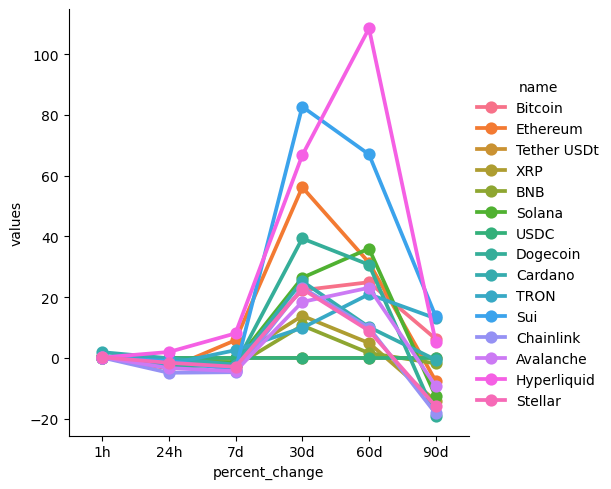

In [36]:
sns.catplot(x='percent_change', y='values', hue='name', data=df6, kind='point')

In [42]:

df10 = df[['name','quote.USD.price','timestamp']]
df10

,name,quote.USD.price,timestamp
0,Bitcoin,103560.22265,2025-05-17 09:16:07.551468
1,Ethereum,2499.67480,2025-05-17 09:16:07.551468
2,Tether USDt,1.00028,2025-05-17 09:16:07.551468
3,XRP,2.38371,2025-05-17 09:16:07.551468
4,BNB,645.02490,2025-05-17 09:16:07.551468
...,...,...,...
70,Sui,3.83097,2025-05-17 09:19:30.405384
71,Chainlink,15.51143,2025-05-17 09:19:30.405384
72,Avalanche,22.96154,2025-05-17 09:19:30.405384
73,Stellar,0.29227,2025-05-17 09:19:30.405384


In [59]:
# if we wanted to query specific columns for our own use

df10 = df10.query("name == 'Bitcoin'")
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,infinite_supply,platform,cmc_rank,self_reported_circulating_supply,self_reported_market_cap,tvl_ratio,last_updated,quote.USD.price,quote.USD.volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12070,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19865290.00000,19865290.00000,False,NaN,1,NaN,NaN,None,2025-05-17T07:15:00.000Z,103560.22265,44147242558.40138,-13.03240,0.05341,-0.40835,-0.22673,22.29222,24.80111,6.27406,2057253855483.59155,62.53580,2174764675731.15991,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
1,1027,Ethereum,ETH,ethereum,10293,2015-08-07T00:00:00.000Z,"[pos, defi, smart-contracts, ethereum-ecosyste...",NaN,120727680.44805,120727680.44805,True,NaN,2,NaN,NaN,None,2025-05-17T07:15:00.000Z,2499.67480,24414632891.28233,-1.07620,0.12261,-3.45034,5.83933,56.14470,31.22162,-7.58096,301779940679.57416,9.17340,301779940679.57001,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
2,825,Tether USDt,USDT,tether,128164,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,151053955711.16483,155507401101.83896,True,NaN,3,NaN,NaN,None,2025-05-17T07:14:00.000Z,1.00028,72244493561.89282,-19.76360,0.02316,0.02989,0.01987,0.03099,0.03866,0.02304,151096311404.22940,4.59300,155551005545.82001,None,2025-05-17T07:14:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-05-17 09:16:07.551468
3,52,XRP,XRP,xrp,1608,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",100000000000.00000,58622147738.00000,99986131469.00000,False,NaN,4,NaN,NaN,None,2025-05-17T07:15:00.000Z,2.38371,3520351447.56323,-37.76750,0.48434,-0.99719,-0.07669,13.80742,4.81954,-14.27957,139738352711.28302,4.24770,238371260868.53000,None,2025-05-17T07:15:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
4,1839,BNB,BNB,bnb,2527,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, defi, paym...",NaN,140888714.26000,140888714.26000,False,NaN,5,NaN,NaN,None,2025-05-17T07:14:00.000Z,645.02490,1596133252.26377,-15.63310,0.13208,-1.84155,-2.66470,10.69304,1.51478,-1.75529,90876728821.33173,2.76240,90876728821.33000,None,2025-05-17T07:14:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:16:07.551468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,20947,Sui,SUI,sui,653,2022-07-12T08:03:11.000Z,"[defi, binance-launchpool, coinbase-ventures-p...",10000000000.00000,3338327017.91167,10000000000.00000,False,NaN,11,3338327017.91167,12789031796.10700,None,2025-05-17T07:18:00.000Z,3.83097,1115748797.06414,-32.81740,-0.00913,-1.06179,-3.80647,82.52433,67.00386,13.48157,12789031796.10700,0.38850,38309703415.78000,None,2025-05-17T07:18:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-05-17 09:19:30.405384
71,1975,Chainlink,LINK,chainlink,2008,2017-09-20T00:00:00.000Z,"[platform, defi, oracles, smart-contracts, eth...",NaN,657099970.45279,1000000000.00000,False,NaN,12,NaN,NaN,None,2025-05-17T07:17:00.000Z,15.51143,395266381.93511,-31.20610,0.09529,-4.88226,-4.68671,23.10062,9.92705,-18.28749,10192559187.26099,0.30970,15511428466.87000,None,2025-05-17T07:17:00.000Z,1027.00000,Ethereum,ETH,ethereum,0x514910771af9ca656af840dff83e8264ecf986ca,2025-05-17 09:19:30.405384
72,5805,Avalanche,AVAX,avalanche,912,2020-07-13T00:00:00.000Z,"[defi, smart-contracts, three-arrows-capital-p...",715748719.00000,420507295.19814,455509995.19814,Fa

<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

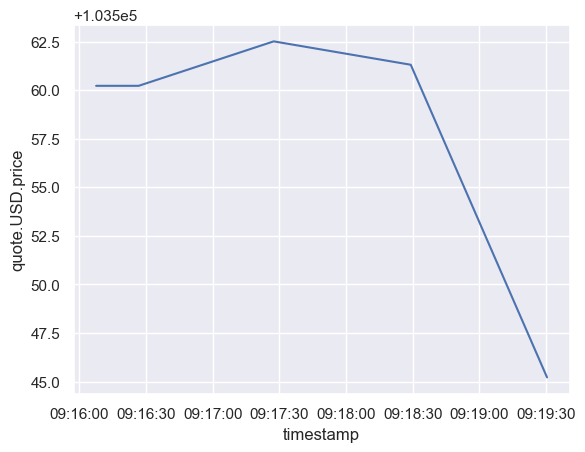

In [61]:
# if we wanted to visualise this properly
sns.set_theme(style="darkgrid")
sns.lineplot(x='timestamp', y='quote.USD.price', data=df10)
